# Model Training

Notebook này thực hiện: load features → split → integrity check → scaling.
Các bước training, threshold tuning và evaluation sẽ nối tiếp bên dưới.

## 1. Setup

Question: Notebook đang dùng input nào và quy ước chia dữ liệu ra sao?

In [2]:
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

FEATURES_PATH = PROJECT_ROOT / "data" / "processed" / "features.csv"

ID_COL = "CONS_NO"
TARGET_COL = "FLAG"

RANDOM_STATE = 42
TRAIN_SIZE = 0.70
VALIDATION_SIZE = 0.15
TEST_SIZE = 0.15

print(f"Features path: {FEATURES_PATH}")
print(f"Split ratio: train={TRAIN_SIZE:.0%}, validation={VALIDATION_SIZE:.0%}, test={TEST_SIZE:.0%}")
print("Note: stratify=y is used to keep the Normal/Theft ratio similar in all splits.")

Features path: d:\UIT\PROJECT\MACHINE-LEARNING-PROJECT\CS114----ML-Project---Energy-Theft-Detection\data\processed\features.csv
Split ratio: train=70%, validation=15%, test=15%
Note: stratify=y is used to keep the Normal/Theft ratio similar in all splits.


## 2. Load Features

Question: `features.csv` có đủ `CONS_NO`, `FLAG` và các feature dùng cho model không?

In [3]:
if not FEATURES_PATH.exists():
    raise FileNotFoundError(
        f"Không tìm thấy {FEATURES_PATH}. Hãy chạy preprocessing_v2.py và feature.py trước."
    )

df = pd.read_csv(FEATURES_PATH)

required_cols = {ID_COL, TARGET_COL}
missing_required_cols = required_cols - set(df.columns)
if missing_required_cols:
    raise ValueError(f"features.csv thiếu cột bắt buộc: {missing_required_cols}")

feature_cols = [col for col in df.columns if col not in [ID_COL, TARGET_COL]]

X = df[feature_cols].copy()
y = df[TARGET_COL].astype(int).copy()
ids = df[ID_COL].copy()

print(f"Dataset shape: {df.shape[0]:,} customers x {df.shape[1]:,} columns")
print(f"Number of model features: {len(feature_cols):,}")
print(f"Target distribution:")
display(y.value_counts().rename(index={0: "Normal", 1: "Theft"}).to_frame("count"))

print("Note: CONS_NO is kept only for tracking customers, not as a model feature.")

Dataset shape: 42,372 customers x 163 columns
Number of model features: 161
Target distribution:


,count
FLAG,
Normal,38757
Theft,3615


Note: CONS_NO is kept only for tracking customers, not as a model feature.


## 3. Train / Validation / Test Split

Question: Chia dữ liệu như thế nào để mỗi split vẫn giữ tỷ lệ `Normal` và `Theft` gần giống dataset gốc?

In [4]:
temp_size = VALIDATION_SIZE + TEST_SIZE
relative_test_size = TEST_SIZE / temp_size

X_train, X_temp, y_train, y_temp, ids_train, ids_temp = train_test_split(
    X,
    y,
    ids,
    test_size=temp_size,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_val, X_test, y_val, y_test, ids_val, ids_test = train_test_split(
    X_temp,
    y_temp,
    ids_temp,
    test_size=relative_test_size,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

ids_train = ids_train.reset_index(drop=True)
ids_val = ids_val.reset_index(drop=True)
ids_test = ids_test.reset_index(drop=True)

print("Split completed.")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

Split completed.
X_train: (29660, 161), y_train: (29660,)
X_val:   (6356, 161), y_val:   (6356,)
X_test:  (6356, 161), y_test:  (6356,)


## 4. Split Check

Question: Sau khi split, tỷ lệ `Theft` trong train/validation/test có còn gần giống nhau không?

In [5]:
def summarize_split(name: str, y_split: pd.Series) -> dict:
    counts = y_split.value_counts().sort_index()
    normal_count = counts.get(0, 0)
    theft_count = counts.get(1, 0)
    total = len(y_split)

    return {
        "split": name,
        "total": total,
        "Normal count": normal_count,
        "Theft count": theft_count,
        "Normal ratio": normal_count / total,
        "Theft ratio": theft_count / total,
    }

split_report = pd.DataFrame(
    [
        summarize_split("full", y),
        summarize_split("train", y_train),
        summarize_split("validation", y_val),
        summarize_split("test", y_test),
    ]
)

display(
    split_report.style.format(
        {
            "Normal ratio": "{:.2%}",
            "Theft ratio": "{:.2%}",
        }
    )
)

print("Observation: Nếu các Theft ratio gần bằng nhau, stratified split đã hoạt động đúng.")

,split,total,Normal count,Theft count,Normal ratio,Theft ratio
0,full,42372,38757,3615,91.47%,8.53%
1,train,29660,27130,2530,91.47%,8.53%
2,validation,6356,5813,543,91.46%,8.54%
3,test,6356,5814,542,91.47%,8.53%


Observation: Nếu các Theft ratio gần bằng nhau, stratified split đã hoạt động đúng.


## 5. Split Integrity Check

Question: Có customer nào bị trùng lặp giữa các split không? Tổng số row có khớp không?

In [6]:
assert len(X_train) + len(X_val) + len(X_test) == len(X), (
    f"Row count mismatch: {len(X_train)} + {len(X_val)} + {len(X_test)} != {len(X)}"
)

assert ids_train.isin(ids_val).sum() == 0, "Overlap detected: train ∩ validation"
assert ids_train.isin(ids_test).sum() == 0, "Overlap detected: train ∩ test"
assert ids_val.isin(ids_test).sum() == 0, "Overlap detected: validation ∩ test"

print("Split integrity check passed: no customer overlap and row counts match.")

Split integrity check passed: no customer overlap and row counts match.


## 6. Feature Scaling

Question: Scaler phải được fit ở đâu để tránh data leakage?

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train),
    columns=feature_cols,
).reset_index(drop=True)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=feature_cols,
).reset_index(drop=True)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
).reset_index(drop=True)

print("Scaling completed: scaler fitted on train only, then applied to validation and test.")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled:   {X_val_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

Scaling completed: scaler fitted on train only, then applied to validation and test.
X_train_scaled: (29660, 161)
X_val_scaled:   (6356, 161)
X_test_scaled:  (6356, 161)


## 7. Shared Variables for Model Training

Các biến chung mà cả 3 thành viên sẽ dùng để train model:

| Biến | Mô tả |
|---|---|
| `X_train_scaled`, `X_val_scaled`, `X_test_scaled` | Feature đã chuẩn hóa |
| `y_train`, `y_val`, `y_test` | Nhãn (0 = Normal, 1 = Theft) |
| `ids_train`, `ids_val`, `ids_test` | CONS_NO, chỉ dùng tracking |

**Lưu ý:**
- `CONS_NO` chỉ dùng để tracking khách hàng, **không** dùng làm feature cho model.
- **Test set chỉ dùng cho final evaluation**, không dùng để chọn model hay tuning threshold.
- Dùng validation set để so sánh model và chọn threshold.

## 8. Evaluation Helper Functions

Vì SGCC Electricity Theft Dataset là dữ liệu mất cân bằng, **Accuracy không nên được dùng làm metric chính**.  
Một mô hình có thể đạt Accuracy cao nếu dự đoán phần lớn khách hàng là normal, nhưng vẫn bỏ sót nhiều khách hàng theft.

Do đó, project này ưu tiên các metric sau:

- **Recall**: đo trong số các khách hàng theft thật, mô hình phát hiện đúng được bao nhiêu.
- **F1-score**: cân bằng giữa Precision và Recall.
- **PR-AUC**: phù hợp hơn khi class dương, tức class theft, chiếm tỷ lệ nhỏ trong dataset.

Trong bài toán phát hiện trộm điện, **False Negative** là lỗi đặc biệt quan trọng.  
False Negative xảy ra khi khách hàng thật sự theft nhưng mô hình lại dự đoán là normal.

Để tránh data leakage, việc chọn model và tune threshold chỉ nên thực hiện trên validation set.  
Test set chỉ nên được dùng một lần ở bước đánh giá cuối cùng sau khi model và threshold đã được chọn.

In [8]:
# STEP 8: Evaluation Helper Functions

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


def get_predictions_at_threshold(y_prob, threshold):
    """
    Chuyển xác suất dự đoán thành nhãn nhị phân dựa trên một threshold cho trước.

    Tham số
    -------
    y_prob : array-like
        Xác suất dự đoán cho class dương, trong project này là class 1 = theft.
    threshold : float
        Ngưỡng phân loại. Nếu xác suất >= threshold thì dự đoán là 1, ngược lại là 0.

    Trả về
    ------
    np.ndarray
        Nhãn dự đoán nhị phân: 0 = normal, 1 = theft.
    """
    y_prob = np.asarray(y_prob)
    return (y_prob >= threshold).astype(int)


def evaluate_binary_classifier(y_true, y_prob, threshold=0.5):
    """
    Đánh giá mô hình binary classification dựa trên xác suất dự đoán và threshold.

    Các metric được tính:
    - Accuracy
    - Precision
    - Recall
    - F1-score
    - ROC-AUC
    - PR-AUC

    Trong đó:
    -------
    ROC-AUC và PR-AUC được tính trực tiếp từ xác suất dự đoán, không dùng nhãn đã threshold.
    Accuracy, Precision, Recall và F1-score được tính từ nhãn dự đoán sau khi áp dụng threshold.
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    y_pred = get_predictions_at_threshold(y_prob, threshold)

    metrics = {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
    }

    return metrics


def plot_confusion_matrix_custom(y_true, y_pred, title):
    """
    Vẽ confusion matrix cho bài toán binary classification.

    Ý nghĩa nhãn:
    - 0 = normal customer
    - 1 = theft customer
    """
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["Normal (0)", "Theft (1)"]
    )

    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, values_format="d", colorbar=False)

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    plt.tight_layout()
    plt.show()

    return cm


def collect_result_row(model_name, split_name, y_true, y_prob, threshold):
    """
    Gom kết quả đánh giá mô hình thành một dictionary phù hợp để tạo bảng báo cáo.

    Tham số
    -------
    model_name : str
        Tên mô hình, ví dụ: "Logistic Regression Baseline".
    split_name : str
        Tên tập dữ liệu được đánh giá, ví dụ: "Validation" hoặc "Test".
    y_true : array-like
        Nhãn thật.
    y_prob : array-like
        Xác suất dự đoán cho class 1.
    threshold : float
        Ngưỡng phân loại dùng để chuyển xác suất thành nhãn 0/1.

    Trả về
    ------
    dict
        Một dòng kết quả gồm tên mô hình, tên split, threshold và các metric đánh giá.
    """
    metrics = evaluate_binary_classifier(
        y_true=y_true, y_prob=y_prob, threshold=threshold
    )

    row = {
        "model": model_name,
        "split": split_name,
        "threshold": metrics["threshold"],
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1_score": metrics["f1_score"],
        "roc_auc": metrics["roc_auc"],
        "pr_auc": metrics["pr_auc"],
    }

    return row

### Ghi chú sử dụng

Các helper function trong bước này sẽ được dùng lại ở những bước sau:

- Logistic Regression baseline
- Logistic Regression với L2 regularization
- Gaussian Discriminant Analysis
- Linear Regression baseline cho mục đích so sánh
- Các model mở rộng nếu cần, ví dụ Random Forest, XGBoost hoặc LightGBM
- Threshold tuning trên validation set
- Đánh giá cuối cùng trên test set
- Phân tích confusion matrix
- Tạo bảng so sánh model để đưa vào báo cáo

Nguyên tắc quan trọng:

**Không tune threshold trên test set.**  
Validation set được dùng để chọn threshold và model phù hợp.  
Test set chỉ dùng sau cùng để đánh giá khả năng generalization của model đã chọn.

## 9. Logistic Regression Baseline

Logistic Regression là mô hình phù hợp cho bài toán **binary classification** vì mô hình trực tiếp ước lượng xác suất một mẫu thuộc class dương:

- `0 = normal customer`
- `1 = theft customer`

Trong bước này, ta train **Logistic Regression baseline** để tạo kết quả tham chiếu ban đầu.  
Baseline này được thiết kế đơn giản nhất có thể: nếu phiên bản `sklearn` hỗ trợ, mô hình sẽ không dùng regularization.

Mục tiêu của baseline là trả lời câu hỏi:

> Với các feature hiện tại, một mô hình Logistic Regression cơ bản có thể phát hiện theft tốt đến mức nào?

Ở bước này, ta chỉ đánh giá trên **validation set** với threshold mặc định `0.5`.  
**Test set chưa được sử dụng** để tránh data leakage. Test set chỉ nên dùng ở bước đánh giá cuối cùng sau khi đã chọn model và threshold.

In [9]:
# STEP 9: Logistic Regression Baseline

from sklearn.linear_model import LogisticRegression

# 9.1. Train Logistic Regression baseline

"""
Baseline này ưu tiên không dùng regularization.
Một số phiên bản sklearn hỗ trợ penalty=None, trong khi một số phiên bản cũ hơn dùng penalty="none".
"""
try:
    logreg_baseline = LogisticRegression(
        penalty=None, solver="lbfgs", max_iter=5000, random_state=RANDOM_STATE
    )

    logreg_baseline.fit(X_train_scaled, y_train)

except Exception as error:
    print("penalty=None không được hỗ trợ trong phiên bản sklearn hiện tại.")
    print("Chuyển sang fallback: penalty='none'")
    print(f"Lỗi gốc: {error}")

    logreg_baseline = LogisticRegression(
        penalty="none", solver="lbfgs", max_iter=5000, random_state=RANDOM_STATE
    )

    logreg_baseline.fit(X_train_scaled, y_train)


# 9.2. Predict probability trên validation set

# predict_proba trả về xác suất cho cả hai class [P(class 0), P(class 1)].
# Ta lấy cột thứ 2 vì class 1 tương ứng với theft customer.
y_val_prob_baseline = logreg_baseline.predict_proba(X_val_scaled)[:, 1]


# 9.3. Evaluate validation set với threshold mặc định 0.5

baseline_threshold = 0.5

baseline_val_row = collect_result_row(
    model_name="Logistic Regression Baseline",
    split_name="Validation",
    y_true=y_val,
    y_prob=y_val_prob_baseline,
    threshold=baseline_threshold,
)

baseline_val_result_df = pd.DataFrame([baseline_val_row])

baseline_val_result_df

,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Logistic Regression Baseline,Validation,0.5,0.91803,0.61,0.112339,0.189736,0.794605,0.351557


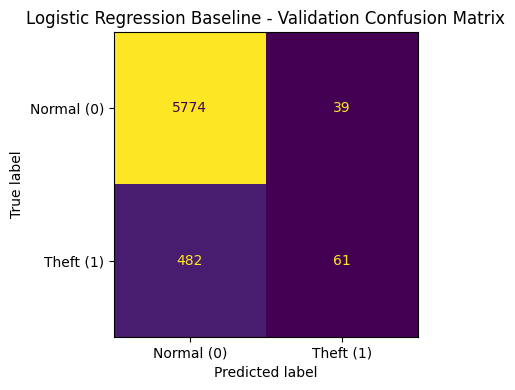

In [10]:
# 9.4. Confusion matrix trên validation set

y_val_pred_baseline = get_predictions_at_threshold(
    y_prob=y_val_prob_baseline, threshold=baseline_threshold
)

baseline_val_cm = plot_confusion_matrix_custom(
    y_true=y_val,
    y_pred=y_val_pred_baseline,
    title="Logistic Regression Baseline - Validation Confusion Matrix",
)

### Nhận Xét:
+ Logistic Regression baseline đạt Accuracy cao trên validation set, nhưng kết quả này chưa phản ánh tốt khả năng phát hiện theft do dữ liệu bị mất cân bằng. Confusion Matrix cho thấy model dự đoán rất tốt class normal với số False Positive thấp, nhưng bỏ sót phần lớn theft customers.

+ Cụ thể, model chỉ phát hiện được 61 trên tổng số 543 theft customers, tương ứng Recall khoảng 11.23%. Điều này cho thấy threshold mặc định 0.5 chưa phù hợp với bài toán Energy Theft Detection, nơi False Negative là lỗi nguy hiểm nhất.

+ Tuy nhiên, ROC-AUC = 0.7946 và PR-AUC = 0.3516 cho thấy model vẫn có khả năng phân biệt nhất định giữa normal và theft. Vì vậy, các bước tiếp theo cần thử Logistic Regression với L2 regularization và thực hiện threshold tuning trên validation set để cải thiện Recall và F1-score.

## 10. Logistic Regression with L2 Regularization

Ở STEP 9, Logistic Regression baseline cho kết quả Recall khá thấp. Điều này cho thấy với threshold mặc định `0.5`, mô hình còn bỏ sót nhiều khách hàng theft.

Trong bước này, ta train **Logistic Regression với L2 regularization**.

**L2 regularization** là kỹ thuật thêm một thành phần phạt vào loss function để hạn chế hệ số của mô hình trở nên quá lớn. Điều này giúp mô hình ổn định hơn và có thể giảm overfitting.

Tham số `C` trong `LogisticRegression` điều khiển mức độ regularization:

- `C` nhỏ => regularization mạnh hơn
- `C` lớn => regularization yếu hơn
- `C = 1.0` là giá trị mặc định thường dùng

Ta chọn `C` dựa trên **validation set**, không dùng test set.  
Validation set được dùng để lựa chọn hyperparameter, còn test set chỉ dùng ở bước đánh giá cuối cùng sau khi model và threshold đã được chọn.

Vì dataset bị mất cân bằng, ta ưu tiên chọn model theo thứ tự:

1. **PR-AUC**: quan trọng khi class theft chiếm tỷ lệ nhỏ.
2. **F1-score**: cân bằng giữa Precision và Recall.
3. **Recall**: đo khả năng phát hiện đúng các khách hàng theft thật.

Ở bước này, ta vẫn giữ threshold mặc định `0.5`.  
Threshold tuning sẽ được thực hiện ở bước sau.

In [11]:
# STEP 10: Logistic Regression with L2 Regularization

from sklearn.linear_model import LogisticRegression

# 10.1. Khai báo grid các giá trị C cần thử

# C càng nhỏ thì regularization càng mạnh.
# C càng lớn thì regularization càng yếu.
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]

l2_result_rows = []
l2_models = {}
l2_val_probabilities = {}

l2_threshold = 0.5


# 10.2. Train và evaluate Logistic Regression L2 cho từng C

for C in C_values:
    model_name = f"Logistic Regression L2 (C={C})"

    logreg_l2 = LogisticRegression(
        penalty="l2", C=C, solver="lbfgs", max_iter=5000, random_state=RANDOM_STATE
    )

    # Train model trên train set.
    logreg_l2.fit(X_train_scaled, y_train)

    # Dự đoán xác suất class 1 = theft trên validation set.
    y_val_prob_l2 = logreg_l2.predict_proba(X_val_scaled)[:, 1]

    # Đánh giá validation set với threshold mặc định 0.5.
    result_row = collect_result_row(
        model_name=model_name,
        split_name="Validation",
        y_true=y_val,
        y_prob=y_val_prob_l2,
        threshold=l2_threshold,
    )

    result_row["C"] = C

    l2_result_rows.append(result_row)
    l2_models[C] = logreg_l2
    l2_val_probabilities[C] = y_val_prob_l2


# 10.3. Tạo bảng so sánh validation metrics cho từng C

l2_results_df = pd.DataFrame(l2_result_rows)

# Sắp xếp theo thứ tự ưu tiên:
# 1. pr_auc giảm dần
# 2. f1_score giảm dần
# 3. recall giảm dần
l2_results_df = l2_results_df.sort_values(
    by=["pr_auc", "f1_score", "recall"], ascending=[False, False, False]
).reset_index(drop=True)

l2_results_df

,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc,C
0,Logistic Regression L2 (C=100.0),Validation,0.5,0.918030,0.610000,0.112339,0.189736,0.794726,0.351561,100.00
1,Logistic Regression L2 (C=10.0),Validation,0.5,0.918030,0.610000,0.112339,0.189736,0.794507,0.350721,10.00
2,Logistic Regression L2 (C=1.0),Validation,0.5,0.918030,0.617021,0.106814,0.182104,0.793735,0.348345,1.00
3,Logistic Regression L2 (C=0.1),Validation,0.5,0.918030,0.641026,0.092081,0.161031,0.793470,0.346926,0.10
4,Logistic Regression L2 (C=0.01),Validation,0.5,0.917873,0.661538,0.079190,0.141447,0.790166,0.339408,0.01


In [12]:
# 10.4. Chọn best C và best L2 model trên validation set

l2_best_row = l2_results_df.iloc[0].to_dict()

logreg_l2_best_C = l2_best_row["C"]
logreg_l2_best = l2_models[logreg_l2_best_C]
y_val_prob_l2_best = l2_val_probabilities[logreg_l2_best_C]

print("Best Logistic Regression L2 model trên validation set")
print(f"Best C       : {logreg_l2_best_C}")
print(f"PR-AUC       : {l2_best_row['pr_auc']:.6f}")
print(f"F1-score     : {l2_best_row['f1_score']:.6f}")
print(f"Recall       : {l2_best_row['recall']:.6f}")
print(f"Precision    : {l2_best_row['precision']:.6f}")
print(f"Accuracy     : {l2_best_row['accuracy']:.6f}")
print(f"ROC-AUC      : {l2_best_row['roc_auc']:.6f}")

Best Logistic Regression L2 model trên validation set
Best C       : 100.0
PR-AUC       : 0.351561
F1-score     : 0.189736
Recall       : 0.112339
Precision    : 0.610000
Accuracy     : 0.918030
ROC-AUC      : 0.794726


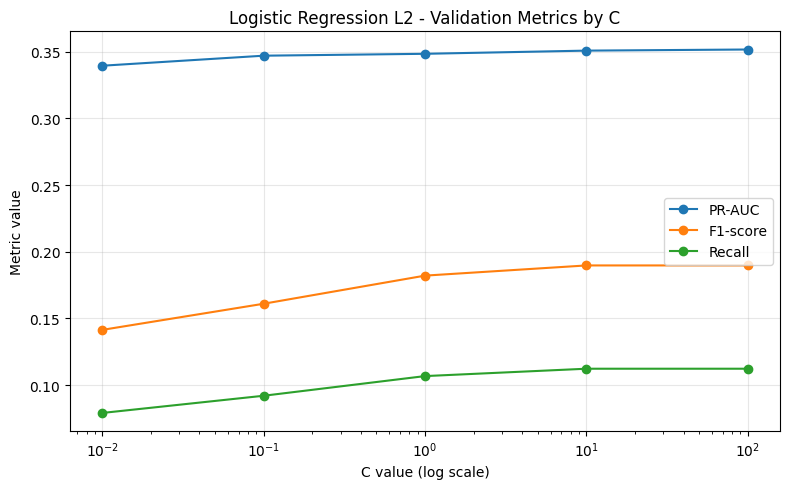

In [13]:
# 10.5. Vẽ biểu đồ PR-AUC, F1-score và Recall theo C

# Để biểu đồ dễ đọc, ta vẽ theo thứ tự C ban đầu thay vì thứ tự đã sort.
l2_plot_df = l2_results_df.sort_values("C").reset_index(drop=True)

plt.figure(figsize=(8, 5))

plt.plot(l2_plot_df["C"], l2_plot_df["pr_auc"], marker="o", label="PR-AUC")

plt.plot(l2_plot_df["C"], l2_plot_df["f1_score"], marker="o", label="F1-score")

plt.plot(l2_plot_df["C"], l2_plot_df["recall"], marker="o", label="Recall")

plt.xscale("log")
plt.xlabel("C value (log scale)")
plt.ylabel("Metric value")
plt.title("Logistic Regression L2 - Validation Metrics by C")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

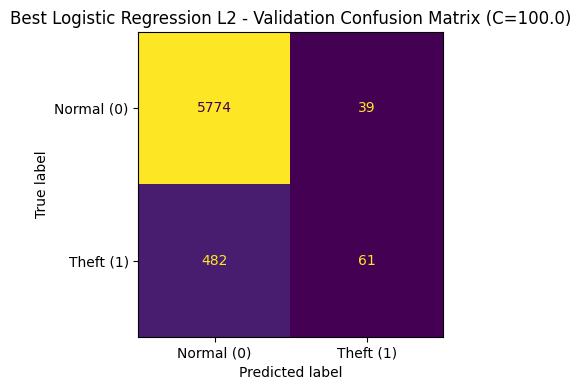

In [14]:
# 10.6. Confusion matrix của best L2 model trên validation set

y_val_pred_l2_best = get_predictions_at_threshold(
    y_prob=y_val_prob_l2_best, threshold=l2_threshold
)

l2_best_val_cm = plot_confusion_matrix_custom(
    y_true=y_val,
    y_pred=y_val_pred_l2_best,
    title=f"Best Logistic Regression L2 - Validation Confusion Matrix (C={logreg_l2_best_C})",
)

### Nhận Xét:
+ Kết quả Logistic Regression với L2 regularization cho thấy model tốt nhất trên validation set đạt được khi C = 100.0. Vì C lớn tương ứng với mức regularization yếu, kết quả này cho thấy regularization mạnh không cải thiện hiệu quả phát hiện theft trong thiết lập hiện tại.

+ So với Logistic Regression baseline, các metric như Accuracy, Precision, Recall và F1-score gần như không thay đổi. ROC-AUC và PR-AUC chỉ tăng rất nhẹ. Confusion Matrix cũng giống baseline, với TP = 61 và FN = 482, cho thấy model vẫn bỏ sót phần lớn khách hàng theft tại threshold mặc định 0.5.

+ Điều này gợi ý rằng vấn đề chính không nằm ở overfitting, mà nằm ở việc threshold mặc định 0.5 chưa phù hợp với dataset mất cân bằng. Do đó, bước tiếp theo cần thực hiện threshold tuning trên validation set để cải thiện Recall và F1-score.

## 11. Threshold Tuning on Validation Set

Ở các bước trước, Logistic Regression baseline và Logistic Regression với L2 đều cho Recall thấp khi dùng threshold mặc định `0.5`. Điều này cho thấy mô hình đang khá “bảo thủ” khi dự đoán class theft.

**Threshold tuning** là quá trình thay đổi ngưỡng phân loại dùng để chuyển xác suất thành nhãn 0/1.

Ví dụ:

- Nếu `threshold = 0.5`, mô hình chỉ dự đoán theft khi xác suất theft >= 0.5.
- Nếu giảm threshold xuống `0.3`, mô hình dễ dự đoán theft hơn.
- Khi đó Recall thường tăng, nhưng Precision có thể giảm.

Với dataset mất cân bằng, threshold mặc định `0.5` thường không tối ưu, đặc biệt khi class theft chiếm tỷ lệ nhỏ. Vì vậy, ta cần thử nhiều threshold khác nhau trên validation set để tìm điểm cân bằng tốt hơn giữa Precision và Recall.

Trong bước này, ta tìm hai loại threshold:

1. **Best F1 threshold**: threshold có F1-score cao nhất, dùng để cân bằng Precision và Recall.
2. **Recall-prioritized threshold**: threshold ưu tiên Recall cao, vì trong bài toán energy theft, bỏ sót khách hàng theft thật là lỗi nghiêm trọng.

Lưu ý quan trọng:

Threshold tuning chỉ được thực hiện trên **validation set**.  
**Test set không được dùng trong bước này** để tránh data leakage. Test set chỉ dùng sau cùng để đánh giá khả năng generalization của model đã chọn.

In [15]:
# STEP 11: Threshold Tuning on Validation Set

# 11.1. Tạo danh sách threshold cần thử

# Thử các threshold từ 0.05 đến 0.95 với bước nhảy 0.01.
# Không dùng threshold quá gần 0 hoặc 1 để tránh các setting quá cực đoan.
thresholds = np.arange(0.05, 0.96, 0.01)

threshold_result_rows = []


# 11.2. Đánh giá best L2 model trên validation set với từng threshold

for threshold in thresholds:
    result_row = collect_result_row(
        model_name=f"Logistic Regression L2 (C={logreg_l2_best_C})",
        split_name="Validation",
        y_true=y_val,
        y_prob=y_val_prob_l2_best,
        threshold=threshold,
    )

    threshold_result_rows.append(result_row)


threshold_results_df = pd.DataFrame(threshold_result_rows)

# Sắp xếp cột để bảng dễ đọc hơn.
threshold_results_df = threshold_results_df[
    [
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

threshold_results_df.head()

,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Logistic Regression L2 (C=100.0),Validation,0.05,0.496381,0.132873,0.885820,0.231083,0.794726,0.351561
1,Logistic Regression L2 (C=100.0),Validation,0.06,0.572687,0.148496,0.845304,0.252614,0.794726,0.351561
2,Logistic Regression L2 (C=100.0),Validation,0.07,0.640812,0.165642,0.793738,0.274086,0.794726,0.351561
3,Logistic Regression L2 (C=100.0),Validation,0.08,0.692889,0.181077,0.736648,0.290698,0.794726,0.351561
4,Logistic Regression L2 (C=100.0),Validation,0.09,0.741661,0.204093,0.697974,0.315833,0.794726,0.351561


In [16]:
# 11.3. Tìm Best F1 threshold

# Best F1 threshold là threshold có f1_score cao nhất.
# Nếu có nhiều threshold cùng F1-score, ưu tiên threshold có recall cao hơn.
best_f1_row = (
    threshold_results_df.sort_values(
        by=["f1_score", "recall", "precision"], ascending=[False, False, False]
    )
    .iloc[0]
    .to_dict()
)

best_f1_threshold = best_f1_row["threshold"]

print("Best F1 threshold trên validation set")
print(f"Threshold : {best_f1_threshold:.2f}")
print(f"Precision : {best_f1_row['precision']:.6f}")
print(f"Recall    : {best_f1_row['recall']:.6f}")
print(f"F1-score  : {best_f1_row['f1_score']:.6f}")
print(f"PR-AUC    : {best_f1_row['pr_auc']:.6f}")
print(f"ROC-AUC   : {best_f1_row['roc_auc']:.6f}")

Best F1 threshold trên validation set
Threshold : 0.16
Precision : 0.356105
Recall    : 0.451197
F1-score  : 0.398050
PR-AUC    : 0.351561
ROC-AUC   : 0.794726


In [17]:
# 11.4. Tìm Recall-prioritized threshold

# Chiến lược:
# - Nếu tồn tại threshold có recall >= 0.60:
#     chọn threshold có f1_score cao nhất trong nhóm đó.
# - Nếu không tồn tại:
#     chọn threshold có recall cao nhất, sau đó f1_score cao nhất.
recall_target = 0.60

recall_candidate_df = threshold_results_df[
    threshold_results_df["recall"] >= recall_target
].copy()

if len(recall_candidate_df) > 0:
    recall_priority_row = (
        recall_candidate_df.sort_values(
            by=["f1_score", "precision", "recall"], ascending=[False, False, False]
        )
        .iloc[0]
        .to_dict()
    )

    print(f"Tìm thấy threshold đạt recall >= {recall_target:.2f}.")
    print("Chọn threshold có F1-score cao nhất trong nhóm này.")

else:
    recall_priority_row = (
        threshold_results_df.sort_values(
            by=["recall", "f1_score", "precision"], ascending=[False, False, False]
        )
        .iloc[0]
        .to_dict()
    )

    print(f"Không có threshold nào đạt recall >= {recall_target:.2f}.")
    print("Chọn threshold có Recall cao nhất, sau đó F1-score cao nhất.")


recall_priority_threshold = recall_priority_row["threshold"]

print("\nRecall-prioritized threshold trên validation set")
print(f"Threshold : {recall_priority_threshold:.2f}")
print(f"Precision : {recall_priority_row['precision']:.6f}")
print(f"Recall    : {recall_priority_row['recall']:.6f}")
print(f"F1-score  : {recall_priority_row['f1_score']:.6f}")
print(f"PR-AUC    : {recall_priority_row['pr_auc']:.6f}")
print(f"ROC-AUC   : {recall_priority_row['roc_auc']:.6f}")

Tìm thấy threshold đạt recall >= 0.60.
Chọn threshold có F1-score cao nhất trong nhóm này.

Recall-prioritized threshold trên validation set
Threshold : 0.11
Precision : 0.242826
Recall    : 0.607735
F1-score  : 0.347003
PR-AUC    : 0.351561
ROC-AUC   : 0.794726


In [18]:
# 11.5. Tạo prediction cho hai threshold đã chọn

y_val_pred_l2_best_f1 = get_predictions_at_threshold(
    y_prob=y_val_prob_l2_best, threshold=best_f1_threshold
)

y_val_pred_l2_recall_priority = get_predictions_at_threshold(
    y_prob=y_val_prob_l2_best, threshold=recall_priority_threshold
)

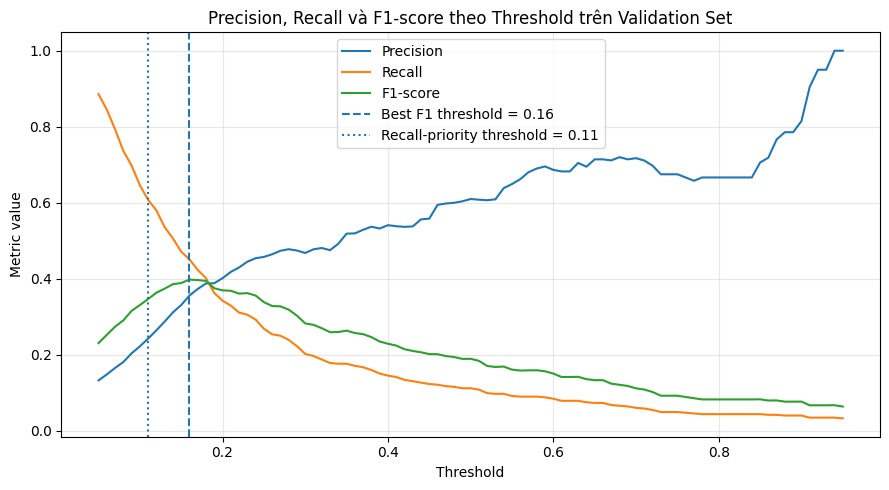

In [19]:
# 11.6. Vẽ Precision, Recall và F1-score theo threshold

plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["precision"],
    label="Precision",
)

plt.plot(
    threshold_results_df["threshold"], threshold_results_df["recall"], label="Recall"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["f1_score"],
    label="F1-score",
)

# Đánh dấu best F1 threshold.
plt.axvline(
    best_f1_threshold,
    linestyle="--",
    label=f"Best F1 threshold = {best_f1_threshold:.2f}",
)

# Đánh dấu recall-prioritized threshold.
plt.axvline(
    recall_priority_threshold,
    linestyle=":",
    label=f"Recall-priority threshold = {recall_priority_threshold:.2f}",
)

plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Precision, Recall và F1-score theo Threshold trên Validation Set")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# 11.7. So sánh 3 setting threshold chính

threshold_05_row = collect_result_row(
    model_name=f"Logistic Regression L2 (C={logreg_l2_best_C})",
    split_name="Validation",
    y_true=y_val,
    y_prob=y_val_prob_l2_best,
    threshold=0.5,
)

threshold_comparison_df = pd.DataFrame(
    [
        {"setting": "Default threshold = 0.5", **threshold_05_row},
        {"setting": "Best F1 threshold", **best_f1_row},
        {"setting": "Recall-prioritized threshold", **recall_priority_row},
    ]
)

threshold_comparison_df = threshold_comparison_df[
    [
        "setting",
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

threshold_comparison_df

,setting,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Default threshold = 0.5,Logistic Regression L2 (C=100.0),Validation,0.50,0.918030,0.610000,0.112339,0.189736,0.794726,0.351561
1,Best F1 threshold,Logistic Regression L2 (C=100.0),Validation,0.16,0.883417,0.356105,0.451197,0.398050,0.794726,0.351561
2,Recall-prioritized threshold,Logistic Regression L2 (C=100.0),Validation,0.11,0.804594,0.242826,0.607735,0.347003,0.794726,0.351561


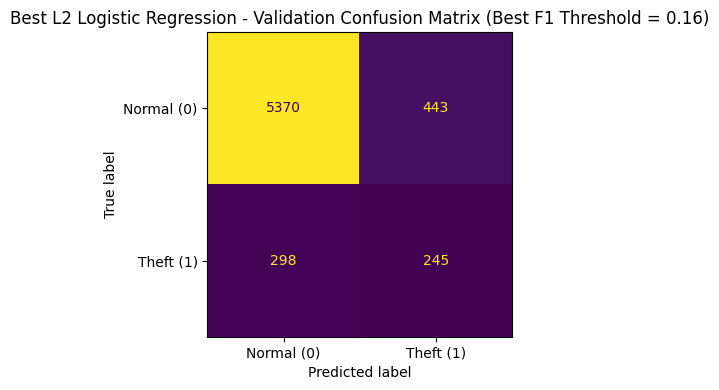

In [21]:
# 11.8. Confusion matrix với Best F1 threshold

best_f1_val_cm = plot_confusion_matrix_custom(
    y_true=y_val,
    y_pred=y_val_pred_l2_best_f1,
    title=(
        "Best L2 Logistic Regression - Validation Confusion Matrix "
        f"(Best F1 Threshold = {best_f1_threshold:.2f})"
    ),
)

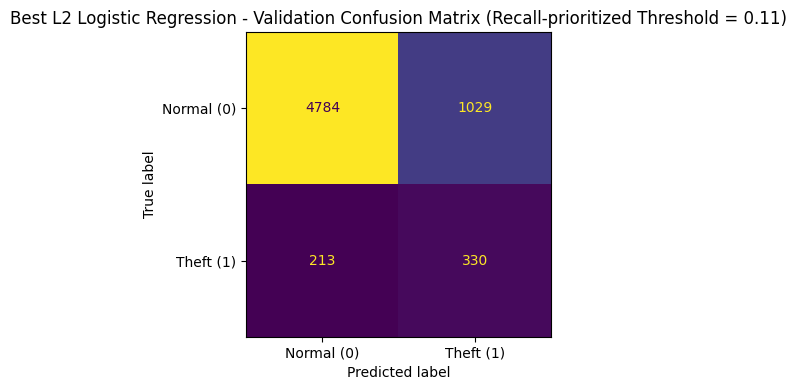

In [22]:
# 11.9. Confusion matrix với Recall-prioritized threshold

recall_priority_val_cm = plot_confusion_matrix_custom(
    y_true=y_val,
    y_pred=y_val_pred_l2_recall_priority,
    title=(
        "Best L2 Logistic Regression - Validation Confusion Matrix "
        f"(Recall-prioritized Threshold = {recall_priority_threshold:.2f})"
    ),
)

### Nhận Xét:
+ Threshold tuning cải thiện rõ rệt khả năng phát hiện theft của Logistic Regression L2. Với threshold mặc định 0.5, model đạt Accuracy cao nhưng Recall chỉ khoảng 11.23%, nghĩa là bỏ sót phần lớn theft customers.

+ Khi giảm threshold xuống 0.16, F1-score đạt giá trị cao nhất trên validation set. Recall tăng từ 11.23% lên 45.12%, trong khi F1-score tăng từ 0.1897 lên 0.3981. Điều này cho thấy threshold mặc định 0.5 không phù hợp với dataset mất cân bằng.

+ Ngoài ra, threshold 0.11 giúp Recall đạt 60.77%, phát hiện được nhiều theft customers hơn, nhưng Precision giảm mạnh và số False Positive tăng đáng kể. Vì vậy, threshold 0.16 được chọn làm threshold chính do cân bằng tốt hơn giữa Precision và Recall, còn threshold 0.11 được dùng để minh họa chiến lược ưu tiên Recall.

## 12. Final Test Evaluation

Ở các bước trước, ta đã chọn:

- Model: **Logistic Regression với L2 regularization**
- Best C: `logreg_l2_best_C`
- Hai threshold từ validation set:
  - **Best F1 threshold**
  - **Recall-prioritized threshold**

Đây là bước đầu tiên sử dụng **test set**.  
Test set chỉ được dùng sau khi model, hyperparameter và threshold đã được chọn xong để tránh data leakage.

Mục tiêu của STEP 12 là đánh giá khả năng **generalization** của model cuối cùng trên dữ liệu chưa từng được dùng trong quá trình train, chọn model hoặc tune threshold.

Ta evaluate test set với 3 threshold:

1. **Default threshold = 0.5**  
   Dùng làm mốc so sánh với threshold mặc định.

2. **Best F1 threshold**  
   Dùng khi muốn cân bằng Precision và Recall.

3. **Recall-prioritized threshold**  
   Dùng khi muốn ưu tiên phát hiện nhiều theft customer hơn, tức giảm False Negative.

Cách đọc kết quả:

- Nếu validation và test có metric gần nhau, model có khả năng generalization tương đối ổn.
- Nếu test kém hơn validation nhiều, có thể model hoặc threshold đang bị overfit theo validation set.
- Nếu Recall tăng nhưng Precision giảm, đó là precision-recall tradeoff bình thường khi hạ threshold.
- Trong bài toán energy theft, cần đặc biệt chú ý Recall và số lượng False Negative.

In [23]:
# STEP 12: Final Test Evaluation

# 12.1. Predict probability trên test set

# Đây là lần đầu tiên test set được sử dụng.
# Không train thêm model, không chọn lại C, không tune thêm threshold trên test set.
# Ta chỉ dùng model L2 tốt nhất đã chọn từ validation set để đánh giá cuối cùng.
y_test_prob_l2_best = logreg_l2_best.predict_proba(X_test_scaled)[:, 1]

In [24]:
# 12.2. Evaluate test set với 3 threshold

test_default_row = collect_result_row(
    model_name=f"Logistic Regression L2 (C={logreg_l2_best_C})",
    split_name="Test",
    y_true=y_test,
    y_prob=y_test_prob_l2_best,
    threshold=0.5,
)

test_best_f1_row = collect_result_row(
    model_name=f"Logistic Regression L2 (C={logreg_l2_best_C})",
    split_name="Test",
    y_true=y_test,
    y_prob=y_test_prob_l2_best,
    threshold=best_f1_threshold,
)

test_recall_priority_row = collect_result_row(
    model_name=f"Logistic Regression L2 (C={logreg_l2_best_C})",
    split_name="Test",
    y_true=y_test,
    y_prob=y_test_prob_l2_best,
    threshold=recall_priority_threshold,
)

test_results_df = pd.DataFrame(
    [
        {"setting": "Default threshold = 0.5", **test_default_row},
        {"setting": "Best F1 threshold", **test_best_f1_row},
        {"setting": "Recall-prioritized threshold", **test_recall_priority_row},
    ]
)

test_results_df = test_results_df[
    [
        "setting",
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

test_results_df

,setting,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Default threshold = 0.5,Logistic Regression L2 (C=100.0),Test,0.50,0.915985,0.542553,0.094096,0.160377,0.773105,0.311792
1,Best F1 threshold,Logistic Regression L2 (C=100.0),Test,0.16,0.871145,0.303546,0.394834,0.343224,0.773105,0.311792
2,Recall-prioritized threshold,Logistic Regression L2 (C=100.0),Test,0.11,0.797514,0.224686,0.560886,0.320844,0.773105,0.311792


In [25]:
# 12.3. Tạo prediction variables trên test set cho các bước sau

y_test_pred_l2_best_f1 = get_predictions_at_threshold(
    y_prob=y_test_prob_l2_best, threshold=best_f1_threshold
)

y_test_pred_l2_recall_priority = get_predictions_at_threshold(
    y_prob=y_test_prob_l2_best, threshold=recall_priority_threshold
)

In [26]:
# 12.4. So sánh validation vs test cho hai threshold đã chọn

# Lưu ý:
# best_f1_row và recall_priority_row là kết quả trên validation set từ STEP 11.
# test_best_f1_row và test_recall_priority_row là kết quả trên test set ở STEP 12.
final_validation_test_comparison_df = pd.DataFrame(
    [
        {"setting": "Best F1 threshold", **best_f1_row},
        {"setting": "Best F1 threshold", **test_best_f1_row},
        {"setting": "Recall-prioritized threshold", **recall_priority_row},
        {"setting": "Recall-prioritized threshold", **test_recall_priority_row},
    ]
)

final_validation_test_comparison_df = final_validation_test_comparison_df[
    [
        "setting",
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

final_validation_test_comparison_df

,setting,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Best F1 threshold,Logistic Regression L2 (C=100.0),Validation,0.16,0.883417,0.356105,0.451197,0.398050,0.794726,0.351561
1,Best F1 threshold,Logistic Regression L2 (C=100.0),Test,0.16,0.871145,0.303546,0.394834,0.343224,0.773105,0.311792
2,Recall-prioritized threshold,Logistic Regression L2 (C=100.0),Validation,0.11,0.804594,0.242826,0.607735,0.347003,0.794726,0.351561
3,Recall-prioritized threshold,Logistic Regression L2 (C=100.0),Test,0.11,0.797514,0.224686,0.560886,0.320844,0.773105,0.311792


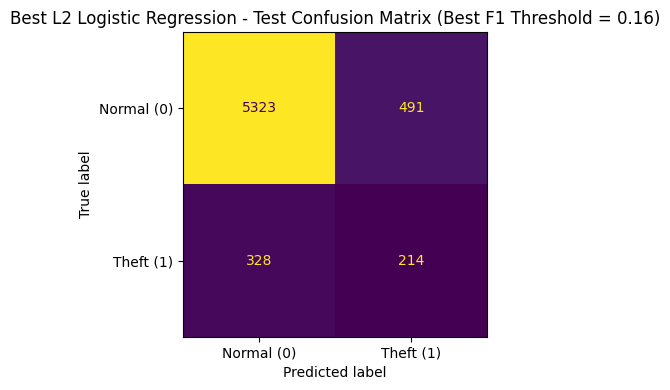

In [27]:
# 12.5. Confusion matrix trên test set với Best F1 threshold

test_best_f1_cm = plot_confusion_matrix_custom(
    y_true=y_test,
    y_pred=y_test_pred_l2_best_f1,
    title=(
        "Best L2 Logistic Regression - Test Confusion Matrix "
        f"(Best F1 Threshold = {best_f1_threshold:.2f})"
    ),
)

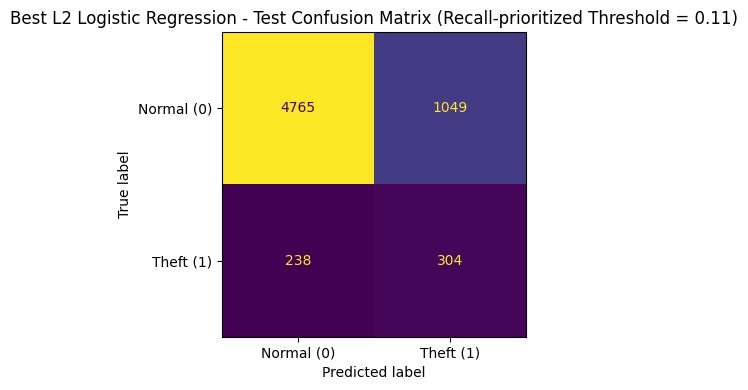

In [28]:
# 12.6. Confusion matrix trên test set với Recall-prioritized threshold

test_recall_priority_cm = plot_confusion_matrix_custom(
    y_true=y_test,
    y_pred=y_test_pred_l2_recall_priority,
    title=(
        "Best L2 Logistic Regression - Test Confusion Matrix "
        f"(Recall-prioritized Threshold = {recall_priority_threshold:.2f})"
    ),
)

### Nhận Xét:
+ Trên test set, Logistic Regression L2 với threshold mặc định 0.5 vẫn đạt Accuracy cao nhưng Recall rất thấp, chỉ khoảng 9.41%. Điều này tiếp tục cho thấy threshold mặc định không phù hợp với bài toán dữ liệu mất cân bằng.

+ Khi sử dụng Best F1 threshold = 0.16 được chọn từ validation set, Recall trên test tăng lên 39.48% và F1-score đạt 0.3432. Mặc dù Precision giảm so với threshold 0.5, model phát hiện được nhiều theft customers hơn đáng kể.

+ Với Recall-prioritized threshold = 0.11, Recall trên test tăng lên 56.09%, nhưng Precision giảm còn 0.2247 và số False Positive tăng mạnh. Do đó, threshold 0.11 phù hợp nếu mục tiêu là giảm False Negative, trong khi threshold 0.16 là lựa chọn cân bằng hơn giữa Precision và Recall.

+ So sánh validation và test cho thấy các metric giảm không quá lớn, đặc biệt với hai threshold đã chọn. Điều này cho thấy model Logistic Regression L2 có khả năng generalization tương đối ổn trên dữ liệu chưa thấy.

## 13. Gaussian Discriminant Analysis

Trong bước này, ta train **Gaussian Discriminant Analysis (GDA)** để làm model so sánh với Logistic Regression.

GDA thuộc nhóm **generative learning**. Thay vì học trực tiếp xác suất \(P(y|x)\), GDA mô hình hóa phân phối dữ liệu theo từng class, tức học:

- \(P(x|y=0)\): phân phối feature của normal customer
- \(P(x|y=1)\): phân phối feature của theft customer
- \(P(y)\): xác suất prior của từng class

Sau đó, model dùng Bayes rule để suy ra xác suất một customer thuộc class theft.

Khác biệt chính:

- **Logistic Regression** là discriminative model, học trực tiếp ranh giới phân loại hoặc xác suất \(P(y|x)\).
- **GDA** là generative model, học cách dữ liệu được sinh ra trong từng class thông qua giả định phân phối Gaussian.

Trong project này, GDA được dùng làm model so sánh để làm rõ sự khác biệt giữa **generative learning** và **discriminative learning**.

Ta ưu tiên dùng `LinearDiscriminantAnalysis` thay vì `QuadraticDiscriminantAnalysis` vì dataset hiện tại có nhiều feature. LDA giả định hai class có covariance matrix giống nhau, nên thường ổn định hơn QDA khi số feature lớn hoặc covariance matrix khó ước lượng chính xác.

Tương tự Logistic Regression, threshold mặc định `0.5` có thể không tối ưu với dữ liệu mất cân bằng. Vì vậy, ta tune threshold trên **validation set**.

Lưu ý quan trọng:

- Validation set được dùng để chọn threshold.
- Test set chỉ dùng để đánh giá cuối cùng.
- Không dùng test set để chọn threshold hoặc chọn model.

In [29]:
# STEP 13: Gaussian Discriminant Analysis

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import warnings

# 13.1. Train Gaussian Discriminant Analysis bằng LDA

# Ta dùng LinearDiscriminantAnalysis như một dạng GDA ổn định hơn cho dữ liệu nhiều feature.
# LDA giả định các class có chung covariance matrix.
# Solver "lsqr" kết hợp shrinkage="auto" giúp tăng ổn định số học khi feature có tương quan cao.
gda_model = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")

# Một số dataset có thể tạo cảnh báo numerical stability do covariance matrix.
# Ở đây ta dùng shrinkage="auto" để giảm rủi ro đó.
with warnings.catch_warnings():
    warnings.simplefilter("always")
    gda_model.fit(X_train_scaled, y_train)


# 13.2. Predict probability trên validation set và test set

# predict_proba trả về [P(class 0), P(class 1)].
# Ta lấy cột class 1 vì class 1 = theft.
y_val_prob_gda = gda_model.predict_proba(X_val_scaled)[:, 1]
y_test_prob_gda = gda_model.predict_proba(X_test_scaled)[:, 1]

In [30]:
# 13.3. Evaluate GDA trên validation set với threshold mặc định 0.5

gda_val_default_row = collect_result_row(
    model_name="Gaussian Discriminant Analysis - LDA",
    split_name="Validation",
    y_true=y_val,
    y_prob=y_val_prob_gda,
    threshold=0.5,
)

gda_val_default_df = pd.DataFrame([gda_val_default_row])

gda_val_default_df

,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Gaussian Discriminant Analysis - LDA,Validation,0.5,0.915198,0.512987,0.145488,0.226686,0.792571,0.335403


In [31]:
# 13.4. Threshold tuning cho GDA trên validation set

gda_thresholds = np.arange(0.05, 0.96, 0.01)

gda_threshold_result_rows = []

for threshold in gda_thresholds:
    result_row = collect_result_row(
        model_name="Gaussian Discriminant Analysis - LDA",
        split_name="Validation",
        y_true=y_val,
        y_prob=y_val_prob_gda,
        threshold=threshold,
    )

    gda_threshold_result_rows.append(result_row)


gda_threshold_results_df = pd.DataFrame(gda_threshold_result_rows)

gda_threshold_results_df = gda_threshold_results_df[
    [
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

gda_threshold_results_df.head()

,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Gaussian Discriminant Analysis - LDA,Validation,0.05,0.675267,0.177070,0.767956,0.287785,0.792571,0.335403
1,Gaussian Discriminant Analysis - LDA,Validation,0.06,0.736784,0.198506,0.685083,0.307820,0.792571,0.335403
2,Gaussian Discriminant Analysis - LDA,Validation,0.07,0.778477,0.222579,0.639042,0.330162,0.792571,0.335403
3,Gaussian Discriminant Analysis - LDA,Validation,0.08,0.808685,0.245654,0.598527,0.348339,0.792571,0.335403
4,Gaussian Discriminant Analysis - LDA,Validation,0.09,0.827722,0.259162,0.546961,0.351687,0.792571,0.335403


In [32]:
# 13.5. Tìm Best F1 threshold cho GDA

# Nếu nhiều threshold có cùng F1-score, ưu tiên recall cao hơn,
# sau đó precision cao hơn.
gda_best_f1_row = (
    gda_threshold_results_df.sort_values(
        by=["f1_score", "recall", "precision"], ascending=[False, False, False]
    )
    .iloc[0]
    .to_dict()
)

gda_best_f1_threshold = gda_best_f1_row["threshold"]

print("GDA - Best F1 threshold trên validation set")
print(f"Threshold : {gda_best_f1_threshold:.2f}")
print(f"Precision : {gda_best_f1_row['precision']:.6f}")
print(f"Recall    : {gda_best_f1_row['recall']:.6f}")
print(f"F1-score  : {gda_best_f1_row['f1_score']:.6f}")
print(f"PR-AUC    : {gda_best_f1_row['pr_auc']:.6f}")
print(f"ROC-AUC   : {gda_best_f1_row['roc_auc']:.6f}")

GDA - Best F1 threshold trên validation set
Threshold : 0.14
Precision : 0.356822
Recall    : 0.438306
F1-score  : 0.393388
PR-AUC    : 0.335403
ROC-AUC   : 0.792571


In [33]:
# 13.6. Tìm Recall-prioritized threshold cho GDA

# Chiến lược giống STEP 11:
# - Nếu tồn tại threshold có recall >= 0.60:
#     chọn threshold có f1_score cao nhất trong nhóm đó.
# - Nếu không tồn tại:
#     chọn threshold có recall cao nhất, sau đó f1_score cao nhất.
gda_recall_target = 0.60

gda_recall_candidate_df = gda_threshold_results_df[
    gda_threshold_results_df["recall"] >= gda_recall_target
].copy()

if len(gda_recall_candidate_df) > 0:
    gda_recall_priority_row = (
        gda_recall_candidate_df.sort_values(
            by=["f1_score", "precision", "recall"], ascending=[False, False, False]
        )
        .iloc[0]
        .to_dict()
    )

    print(f"Tìm thấy threshold GDA đạt recall >= {gda_recall_target:.2f}.")
    print("Chọn threshold có F1-score cao nhất trong nhóm này.")

else:
    gda_recall_priority_row = (
        gda_threshold_results_df.sort_values(
            by=["recall", "f1_score", "precision"], ascending=[False, False, False]
        )
        .iloc[0]
        .to_dict()
    )

    print(f"Không có threshold GDA nào đạt recall >= {gda_recall_target:.2f}.")
    print("Chọn threshold có Recall cao nhất, sau đó F1-score cao nhất.")


gda_recall_priority_threshold = gda_recall_priority_row["threshold"]

print("\nGDA - Recall-prioritized threshold trên validation set")
print(f"Threshold : {gda_recall_priority_threshold:.2f}")
print(f"Precision : {gda_recall_priority_row['precision']:.6f}")
print(f"Recall    : {gda_recall_priority_row['recall']:.6f}")
print(f"F1-score  : {gda_recall_priority_row['f1_score']:.6f}")
print(f"PR-AUC    : {gda_recall_priority_row['pr_auc']:.6f}")
print(f"ROC-AUC   : {gda_recall_priority_row['roc_auc']:.6f}")

Tìm thấy threshold GDA đạt recall >= 0.60.
Chọn threshold có F1-score cao nhất trong nhóm này.

GDA - Recall-prioritized threshold trên validation set
Threshold : 0.07
Precision : 0.222579
Recall    : 0.639042
F1-score  : 0.330162
PR-AUC    : 0.335403
ROC-AUC   : 0.792571


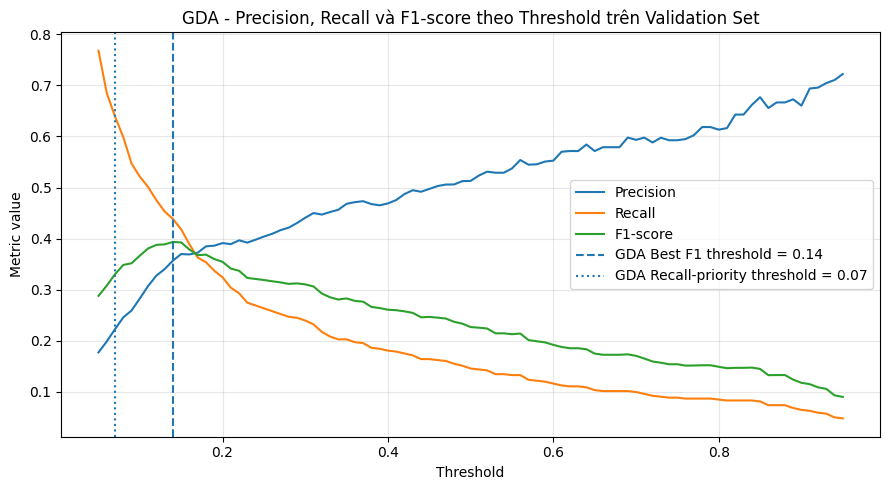

In [34]:
# 13.7. Vẽ Precision, Recall và F1-score theo threshold của GDA

plt.figure(figsize=(9, 5))

plt.plot(
    gda_threshold_results_df["threshold"],
    gda_threshold_results_df["precision"],
    label="Precision",
)

plt.plot(
    gda_threshold_results_df["threshold"],
    gda_threshold_results_df["recall"],
    label="Recall",
)

plt.plot(
    gda_threshold_results_df["threshold"],
    gda_threshold_results_df["f1_score"],
    label="F1-score",
)

plt.axvline(
    gda_best_f1_threshold,
    linestyle="--",
    label=f"GDA Best F1 threshold = {gda_best_f1_threshold:.2f}",
)

plt.axvline(
    gda_recall_priority_threshold,
    linestyle=":",
    label=f"GDA Recall-priority threshold = {gda_recall_priority_threshold:.2f}",
)

plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("GDA - Precision, Recall và F1-score theo Threshold trên Validation Set")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
# 13.8. Evaluate GDA trên test set với 3 threshold

# Không tune threshold trên test set.
# Ba threshold dưới đây đã được xác định trước:
# - 0.5 là threshold mặc định
# - gda_best_f1_threshold chọn từ validation set
# - gda_recall_priority_threshold chọn từ validation set
gda_test_default_row = collect_result_row(
    model_name="Gaussian Discriminant Analysis - LDA",
    split_name="Test",
    y_true=y_test,
    y_prob=y_test_prob_gda,
    threshold=0.5,
)

gda_test_best_f1_row = collect_result_row(
    model_name="Gaussian Discriminant Analysis - LDA",
    split_name="Test",
    y_true=y_test,
    y_prob=y_test_prob_gda,
    threshold=gda_best_f1_threshold,
)

gda_test_recall_priority_row = collect_result_row(
    model_name="Gaussian Discriminant Analysis - LDA",
    split_name="Test",
    y_true=y_test,
    y_prob=y_test_prob_gda,
    threshold=gda_recall_priority_threshold,
)

gda_test_results_df = pd.DataFrame(
    [
        {"setting": "GDA default threshold = 0.5", **gda_test_default_row},
        {"setting": "GDA Best F1 threshold", **gda_test_best_f1_row},
        {"setting": "GDA Recall-prioritized threshold", **gda_test_recall_priority_row},
    ]
)

gda_test_results_df = gda_test_results_df[
    [
        "setting",
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

gda_test_results_df

,setting,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,GDA default threshold = 0.5,Gaussian Discriminant Analysis - LDA,Test,0.50,0.915828,0.524138,0.140221,0.221252,0.772393,0.308164
1,GDA Best F1 threshold,Gaussian Discriminant Analysis - LDA,Test,0.14,0.872089,0.299259,0.372694,0.331964,0.772393,0.308164
2,GDA Recall-prioritized threshold,Gaussian Discriminant Analysis - LDA,Test,0.07,0.768880,0.203455,0.586716,0.302138,0.772393,0.308164


In [36]:
# 13.9. Tạo prediction variables cho GDA trên test set

y_test_pred_gda_best_f1 = get_predictions_at_threshold(
    y_prob=y_test_prob_gda, threshold=gda_best_f1_threshold
)

y_test_pred_gda_recall_priority = get_predictions_at_threshold(
    y_prob=y_test_prob_gda, threshold=gda_recall_priority_threshold
)

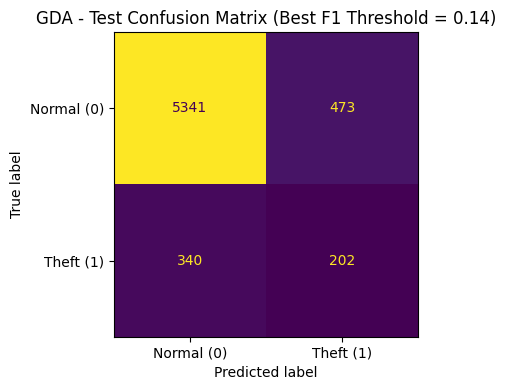

In [37]:
# 13.10. Confusion matrix trên test set với GDA Best F1 threshold

gda_test_best_f1_cm = plot_confusion_matrix_custom(
    y_true=y_test,
    y_pred=y_test_pred_gda_best_f1,
    title=(
        "GDA - Test Confusion Matrix "
        f"(Best F1 Threshold = {gda_best_f1_threshold:.2f})"
    ),
)

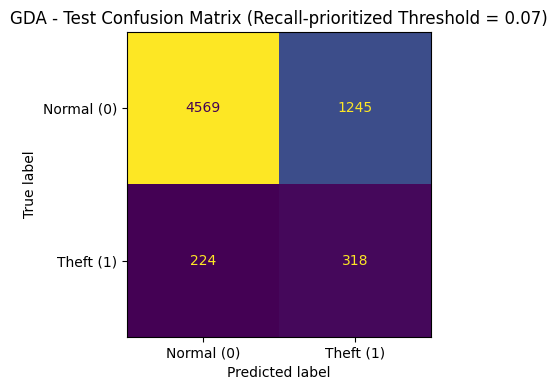

In [38]:
# 13.11. Confusion matrix trên test set với GDA Recall-prioritized threshold

gda_test_recall_priority_cm = plot_confusion_matrix_custom(
    y_true=y_test,
    y_pred=y_test_pred_gda_recall_priority,
    title=(
        "GDA - Test Confusion Matrix "
        f"(Recall-prioritized Threshold = {gda_recall_priority_threshold:.2f})"
    ),
)

In [39]:
# 13.12. So sánh ngắn Logistic Regression L2 và GDA trên test set

"""
Các biến test_best_f1_row và test_recall_priority_row đã được tạo ở STEP 12
cho Logistic Regression L2 final model.
"""

model_comparison_test_df = pd.DataFrame(
    [
        {
            "comparison_setting": "Logistic Regression L2 - Best F1 threshold",
            **test_best_f1_row,
        },
        {"comparison_setting": "GDA - Best F1 threshold", **gda_test_best_f1_row},
        {
            "comparison_setting": "Logistic Regression L2 - Recall-prioritized threshold",
            **test_recall_priority_row,
        },
        {
            "comparison_setting": "GDA - Recall-prioritized threshold",
            **gda_test_recall_priority_row,
        },
    ]
)

model_comparison_test_df = model_comparison_test_df[
    [
        "comparison_setting",
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

model_comparison_test_df

,comparison_setting,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Logistic Regression L2 - Best F1 threshold,Logistic Regression L2 (C=100.0),Test,0.16,0.871145,0.303546,0.394834,0.343224,0.773105,0.311792
1,GDA - Best F1 threshold,Gaussian Discriminant Analysis - LDA,Test,0.14,0.872089,0.299259,0.372694,0.331964,0.772393,0.308164
2,Logistic Regression L2 - Recall-prioritized th...,Logistic Regression L2 (C=100.0),Test,0.11,0.797514,0.224686,0.560886,0.320844,0.773105,0.311792
3,GDA - Recall-prioritized threshold,Gaussian Discriminant Analysis - LDA,Test,0.07,0.768880,0.203455,0.586716,0.302138,0.772393,0.308164


### Nhận Xét:
+ Kết quả so sánh cho thấy Gaussian Discriminant Analysis thông qua Linear Discriminant Analysis đạt hiệu năng khá gần Logistic Regression L2, nhưng nhìn chung vẫn kém hơn nhẹ ở các metric quan trọng như F1-score, ROC-AUC và PR-AUC.

+ Ở Best F1 threshold, Logistic Regression L2 đạt F1-score cao hơn GDA và phát hiện được nhiều theft customers hơn, dù GDA có số False Positive thấp hơn một chút. Ở Recall-prioritized threshold, GDA đạt Recall cao hơn, nhưng phải đánh đổi bằng số False Positive lớn hơn đáng kể, làm Precision và F1-score thấp hơn Logistic Regression L2.

+ Điều này cho thấy GDA có thể phát hiện thêm một số theft cases khi giảm threshold mạnh, nhưng Logistic Regression L2 tạo ra trade-off cân bằng và ổn định hơn. Kết quả này cũng phù hợp về mặt lý thuyết vì Logistic Regression là discriminative model, học trực tiếp xác suất P(y|x), trong khi GDA dựa trên giả định phân phối Gaussian của feature theo từng class. Với các feature hành vi tiêu thụ điện phức tạp, giả định Gaussian có thể không phù hợp hoàn toàn.

+ Do đó, Logistic Regression L2 vẫn được giữ làm model chính, còn GDA đóng vai trò model so sánh để minh họa sự khác biệt giữa generative learning và discriminative learning.